# Split 目录的序列相似性与口袋结构相似性检查

本 notebook 可用于检测任意 Interformer-compatible split 目录。只需要在参数 cell 中修改 `ANALYSIS_SPLIT_DIR`，目录下应包含：

- `timesplit_no_lig_overlap_train`
- `timesplit_no_lig_overlap_val`
- `timesplit_test`

Notebook 会重新生成 PDBbind split 表，检查不同数据集之间的蛋白序列相似性与 binding pocket 结构相似性，并输出相似 ID、读取到的原始数据字段和可视化图表。

默认检测根目录 `split/`，也可以改成新生成的目录，例如 `split_sequence_cluster_interformer_union/` 或 `split_sequence_cluster_all_raw/`。


In [17]:
from pathlib import Path
import json
import math
import os
import sys

import pandas as pd
from IPython.display import HTML, display

# 自动定位项目根目录。这样无论从项目根目录还是 notebooks/ 目录启动 notebook，
# 都可以正确 import scripts/ 下的本地模块。
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'split_similarity_analysis.py').exists():
            return candidate
    raise RuntimeError('无法定位项目根目录：没有找到 scripts/split_similarity_analysis.py')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Matplotlib 在当前沙箱中不能写 ~/.matplotlib，因此把缓存目录放到项目内。
MPLCONFIGDIR = PROJECT_ROOT / 'data/processed/matplotlib_cache'
XDG_CACHE_HOME = PROJECT_ROOT / 'data/processed/font_cache'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
XDG_CACHE_HOME.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR.resolve()))
os.environ.setdefault('XDG_CACHE_HOME', str(XDG_CACHE_HOME.resolve()))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from matplotlib import font_manager

# 配置中文字体。macOS 上优先使用覆盖面较好的 Arial Unicode MS，
# 找不到时回退到 Hiragino Sans GB / STHeiti / Songti SC。
CJK_FONT_CANDIDATES = [
    Path('/Library/Fonts/Arial Unicode.ttf'),
    Path('/System/Library/Fonts/Supplemental/Arial Unicode.ttf'),
    Path('/System/Library/Fonts/Hiragino Sans GB.ttc'),
    Path('/System/Library/Fonts/STHeiti Medium.ttc'),
    Path('/System/Library/Fonts/Supplemental/Songti.ttc'),
]
CJK_FONT_NAME = None
for font_path in CJK_FONT_CANDIDATES:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        CJK_FONT_NAME = font_manager.FontProperties(fname=str(font_path)).get_name()
        break
if CJK_FONT_NAME:
    plt.rcParams['font.family'] = [CJK_FONT_NAME, 'DejaVu Sans']
else:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'STHeiti', 'Songti SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


from scripts.split_similarity_analysis import (
    OUTPUT_DIR as DEFAULT_OUTPUT_DIR,
    SPLIT_CSV,
    build_pocket_feature_table,
    check_cross_split_sequence_similarity,
    compute_cross_split_pocket_similarity,
    html_table,
    prepare_split_table,
    summary_heatmap_html,
    svg_histogram,
)

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

PROJECT_ROOT, DEFAULT_OUTPUT_DIR


(PosixPath('/Users/songni/canvas.nosync/ai3624/final_project'),
 PosixPath('/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis'))

In [18]:
# =============================
# 参数入口：修改这里即可检测任意 split 目录
# =============================
# 例子：
# ANALYSIS_SPLIT_DIR = PROJECT_ROOT / 'split'
ANALYSIS_SPLIT_DIR = PROJECT_ROOT / 'split_sequence_cluster_interformer_union'
# ANALYSIS_SPLIT_DIR = PROJECT_ROOT / 'split_sequence_cluster_all_raw'
# ANALYSIS_SPLIT_DIR = PROJECT_ROOT / 'split'

# 每个 split 目录单独写到一个输出子目录，避免不同实验结果互相覆盖。
ANALYSIS_NAME = ANALYSIS_SPLIT_DIR.name
OUTPUT_DIR = DEFAULT_OUTPUT_DIR / ANALYSIS_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 序列泄漏阈值。含义是：identity >= 40% 且 coverage >= 80% 的跨 split 命中视为不满足约束。
MIN_SEQ_ID = 0.4
COVERAGE = 0.8
MIN_CHAIN_LENGTH = 30

# pocket 相似性是抽样计算；调大会更全面但更慢。
POCKET_SAMPLE_PER_SPLIT = 250
POCKET_RANDOM_STATE = 42

ANALYSIS_SPLIT_DIR, OUTPUT_DIR


(PosixPath('/Users/songni/canvas.nosync/ai3624/final_project/split_sequence_cluster_interformer_union'),
 PosixPath('/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split_sequence_cluster_interformer_union'))

In [19]:
# =============================
# 轻量 SVG 散点图工具：不依赖 matplotlib / seaborn
# =============================
def svg_scatter(
    df,
    x,
    y,
    color,
    title,
    x_label=None,
    y_label=None,
    width=780,
    height=360,
    max_points=2500,
):
    plot_df = df[[x, y, color]].dropna().copy()
    if len(plot_df) > max_points:
        plot_df = plot_df.sample(max_points, random_state=42)
    if plot_df.empty:
        return f"<svg width='{width}' height='{height}'><text x='20' y='40'>{title}: no data</text></svg>"

    x_values = pd.to_numeric(plot_df[x], errors='coerce')
    y_values = pd.to_numeric(plot_df[y], errors='coerce')
    plot_df = plot_df[x_values.notna() & y_values.notna()].copy()
    x_values = pd.to_numeric(plot_df[x], errors='coerce')
    y_values = pd.to_numeric(plot_df[y], errors='coerce')
    if plot_df.empty:
        return f"<svg width='{width}' height='{height}'><text x='20' y='40'>{title}: no numeric data</text></svg>"

    left, right, top, bottom = 70, 24, 42, 58
    chart_w = width - left - right
    chart_h = height - top - bottom
    x_min, x_max = float(x_values.min()), float(x_values.max())
    y_min, y_max = float(y_values.min()), float(y_values.max())
    if x_min == x_max:
        x_min -= 1
        x_max += 1
    if y_min == y_max:
        y_min -= 1
        y_max += 1

    palette = {
        'train': '#4f7fba',
        'valid': '#c58b31',
        'test': '#c85454',
        'train_vs_valid': '#8a63a8',
        'train_vs_test': '#c85454',
        'valid_vs_test': '#5f9b72',
    }
    categories = list(dict.fromkeys(plot_df[color].astype(str).tolist()))
    fallback = ['#4f7fba', '#c85454', '#5f9b72', '#8a63a8', '#c58b31', '#6b6b6b']

    circles = []
    for row in plot_df.itertuples(index=False):
        xv = float(getattr(row, x))
        yv = float(getattr(row, y))
        cat = str(getattr(row, color))
        px = left + (xv - x_min) / (x_max - x_min) * chart_w
        py = top + chart_h - (yv - y_min) / (y_max - y_min) * chart_h
        fill = palette.get(cat, fallback[categories.index(cat) % len(fallback)])
        circles.append(f"<circle cx='{px:.1f}' cy='{py:.1f}' r='3.0' fill='{fill}' fill-opacity='0.62'><title>{cat}: {x}={xv:.3f}, {y}={yv:.3f}</title></circle>")

    legend = []
    for idx, cat in enumerate(categories):
        fill = palette.get(cat, fallback[idx % len(fallback)])
        lx = left + idx * 130
        ly = height - 18
        legend.append(f"<circle cx='{lx}' cy='{ly}' r='5' fill='{fill}'/><text x='{lx + 9}' y='{ly + 4}' font-size='12'>{cat}</text>")

    return f"""
    <svg width="{width}" height="{height}" viewBox="0 0 {width} {height}" xmlns="http://www.w3.org/2000/svg">
      <style>text {{ font-family: -apple-system, BlinkMacSystemFont, sans-serif; fill: #222; }}</style>
      <text x="{left}" y="24" font-size="16" font-weight="700">{title}</text>
      <line x1="{left}" y1="{top + chart_h}" x2="{left + chart_w}" y2="{top + chart_h}" stroke="#222"/>
      <line x1="{left}" y1="{top}" x2="{left}" y2="{top + chart_h}" stroke="#222"/>
      <text x="{left}" y="{height - 36}" font-size="12">{x_min:.2f}</text>
      <text x="{left + chart_w - 46}" y="{height - 36}" font-size="12">{x_max:.2f}</text>
      <text x="8" y="{top + chart_h}" font-size="12">{y_min:.2f}</text>
      <text x="8" y="{top + 8}" font-size="12">{y_max:.2f}</text>
      <text x="{left + chart_w / 2 - 45}" y="{height - 36}" font-size="12">{x_label or x}</text>
      <text x="10" y="{top - 12}" font-size="12">{y_label or y}</text>
      {''.join(circles)}
      {''.join(legend)}
    </svg>
    """


In [20]:
# =============================
# Matplotlib 散点图工具
# =============================
def plot_scatter_by_category(df, x, y, category, title, x_label=None, y_label=None, max_points=4000):
    """按类别绘制散点图；用于观察 train/valid/test 或 split-pair 的数值范围。"""
    plot_df = df[[x, y, category]].dropna().copy()
    if len(plot_df) > max_points:
        plot_df = plot_df.sample(max_points, random_state=42)
    if plot_df.empty:
        print(f'{title}: no data')
        return None

    palette = {
        'train': '#4f7fba',
        'valid': '#c58b31',
        'test': '#c85454',
        'train_vs_valid': '#8a63a8',
        'train_vs_test': '#c85454',
        'valid_vs_test': '#5f9b72',
    }
    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    for name, part in plot_df.groupby(category):
        ax.scatter(
            pd.to_numeric(part[x], errors='coerce'),
            pd.to_numeric(part[y], errors='coerce'),
            s=15,
            alpha=0.62,
            label=str(name),
            color=palette.get(str(name)),
            edgecolors='none',
        )
    ax.set_title(title)
    ax.set_xlabel(x_label or x)
    ax.set_ylabel(y_label or y)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    return fig


## 1. 读取待检测 split 目录并生成可审计划分表

这里会读取 `ANALYSIS_SPLIT_DIR` 指向的目录，将其中的 train/valid/test ID 文件与本地 PDBbind 原始 index 和结构目录匹配，生成每个 complex 的 split、蛋白路径、pocket 路径和配体路径。


In [21]:
split_df, split_report = prepare_split_table(split_dir=ANALYSIS_SPLIT_DIR, output_dir=OUTPUT_DIR)

summary_keys = [
    'raw_rows',
    'primary_split_file_counts',
    'matched_primary_split_counts',
    'unassigned_raw_rows',
    'primary_split_overlap_counts',
    'split_ids_missing_from_raw_counts',
    'eval_subset_counts_in_raw',
]
print(f'当前检测目录: {ANALYSIS_SPLIT_DIR}')
print(f'输出目录: {OUTPUT_DIR}')
{key: split_report[key] for key in summary_keys}

当前检测目录: /Users/songni/canvas.nosync/ai3624/final_project/split_sequence_cluster_interformer_union
输出目录: /Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split_sequence_cluster_interformer_union


{'raw_rows': 19037,
 'primary_split_file_counts': {'train': 16038, 'valid': 945, 'test': 356},
 'matched_primary_split_counts': {'train': 16038, 'valid': 945, 'test': 356},
 'unassigned_raw_rows': 1698,
 'primary_split_overlap_counts': {'test_vs_train': 0,
  'test_vs_valid': 0,
  'train_vs_valid': 0},
 'split_ids_missing_from_raw_counts': {'train': 0, 'valid': 0, 'test': 0},
 'eval_subset_counts_in_raw': {'is_coreset': 2,
  'is_diff_test_core': 2,
  'is_posebusters_pdb_ccd': 0,
  'is_test_no_rec_overlap': 0,
  'is_test_sanitizable': 0}}

In [22]:
split_counts = split_df['split'].value_counts().rename_axis('split').reset_index(name='complex_count')
display(split_counts)
display(split_df.groupby('split')[['has_protein', 'has_pocket', 'has_ligand_sdf']].sum().astype(int))
split_df.head(5)

,split,complex_count
0,train,16038
1,unassigned,1698
2,valid,945
3,test,356


,has_protein,has_pocket,has_ligand_sdf
split,,,
test,356,356,356
train,16038,16038,16038
unassigned,1698,1698,1698
valid,945,945,945


,split,split_source,line_number,pdb_id,resolution,release_year,raw_affinity,reference,ligand_name,comment,raw_line,index_parse_ok,affinity_type,affinity_relation,affinity_value,affinity_unit,affinity_molar,pAffinity,affinity_parse_ok,resolution_numeric,complex_dir,year_bucket,protein_path,has_protein,protein_bytes,pocket_path,has_pocket,pocket_bytes,ligand_sdf_path,has_ligand_sdf,ligand_sdf_bytes,ligand_mol2_path,has_ligand_mol2,ligand_mol2_bytes,is_coreset,is_diff_test_core,is_posebusters_pdb_ccd,is_test_no_rec_overlap,is_test_sanitizable
0,train,Interformer timesplit/no-lig-overlap files,7,2tpi,2.10,1982,Kd=49uM,2tpi.pdf,2-mer,,2tpi 2.10 1982 Kd=49uM // 2tpi.pdf (2-mer),True,Kd,=,49.00,uM,4.900000e-05,4.309804,True,2.1,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/2tpi,1981-2000,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/2tpi/2tpi_protein.pdb,True,343278,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/2tpi/2tpi_pocket.pdb,True,87237,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/2tpi/2tpi_ligand.sdf,True,2766,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/2tpi/2tpi_ligand.mol2,True,3837,False,False,False,False,False
1,train,Interformer timesplit/no-lig-overlap files,8,5tln,2.30,1982,Ki=0.43uM,5tln.pdf,BAN,incomplete ligand structure,5tln 2.30 1982 Ki=0.43uM // 5tln.pdf (BAN) incomplete ligand structure,True,Ki,=,0.43,uM,4.300000e-07,6.366532,True,2.3,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/5tln,1981-2000,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/5tln/5tln_protein.pdb,True,395361,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/5tln/5tln_pocket.pdb,True,101574,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/5tln/5tln_ligand.sdf,True,3211,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/5tln/5tln_ligand.mol2,True,4444,False,False,False,False,False
2,train,Interformer timesplit/no-lig-overlap files,9,4tln,2.30,1982,Ki=190uM,4tln.pdf,LNO,,4tln 2.30 1982 Ki=190uM // 4tln.pdf (LNO),True,Ki,=,190.00,uM,1.900000e-04,3.721246,True,2.3,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4tln,1981-2000,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4tln/4tln_protein.pdb,True,395685,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4tln/4tln_pocket.pdb,True,84402,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4tln/4tln_ligand.sdf,True,1843,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4tln/4tln_ligand.mol2,True,2574,False,False,False,False,False
3,train,Interformer timesplit/no-lig-overlap files,10,4cts,2.90,1984,Kd<10uM,4cts.pdf,OAA,,4cts 2.90 1984 Kd<10uM // 4cts.pdf (OAA),True,Kd,<,10.00,uM,1.000000e-05,5.000000,True,2.9,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4cts,1981-2000,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4cts/4cts_protein.pdb,True,1128978,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4cts/4cts_pocket.pdb,True,93312,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4cts/4cts_ligand.sdf,True,849,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4cts/4cts_ligand.mol2,True,1219,False,False,False,False,False
4,train,Interformer timesplit/no-lig-overlap files,11,6rsa,NMR,1986,Ki=40uM,6rsa.pdf,UV

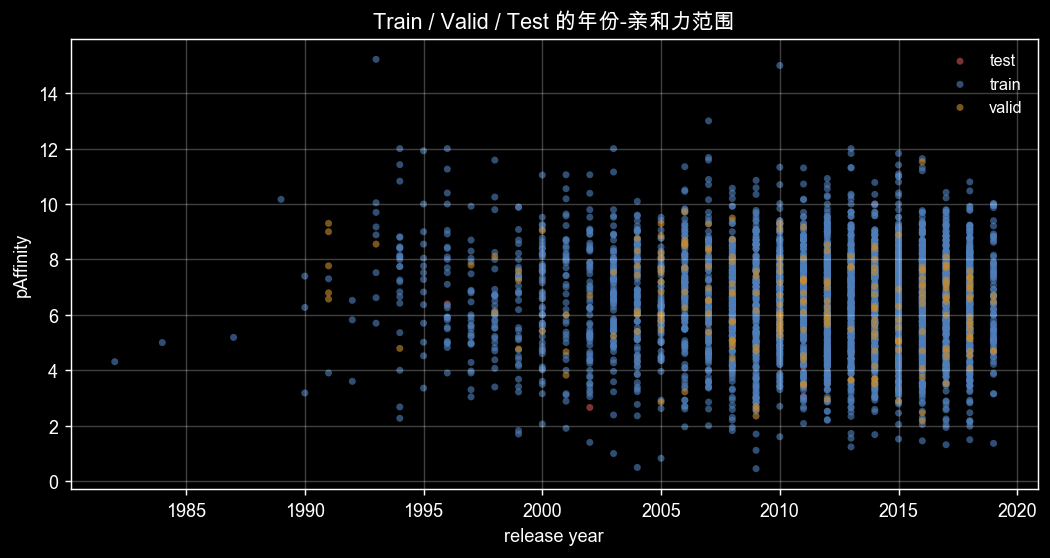

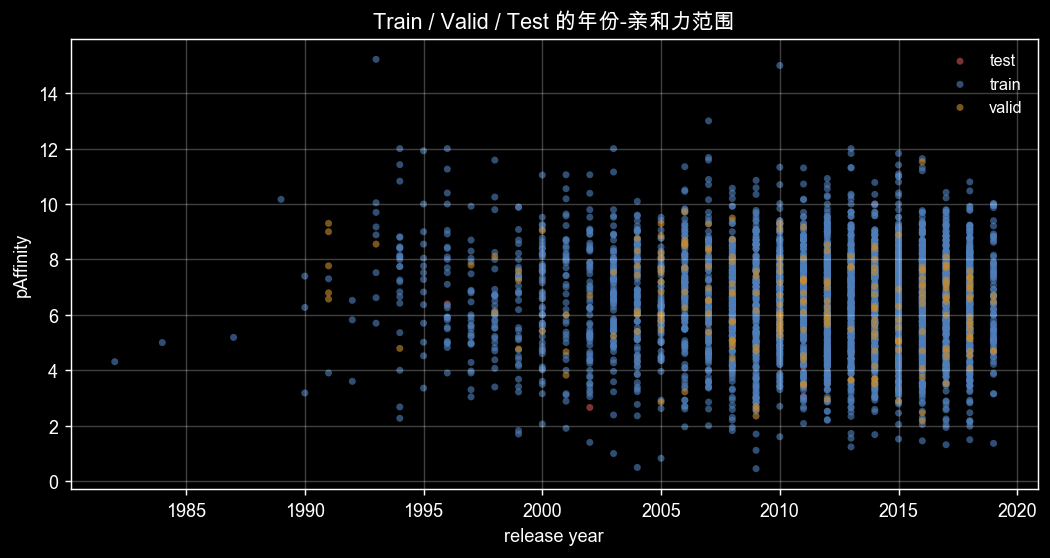

In [23]:
# 可视化三个类别的数据范围：release_year 与 pAffinity 的二维分布。
# 这能帮助判断待检测 split 是否在标签和值域上出现明显偏移。
plot_df = split_df[split_df['split'].isin(['train', 'valid', 'test'])].copy()
plot_df['release_year_numeric'] = pd.to_numeric(plot_df['release_year'], errors='coerce')
plot_df['pAffinity_numeric'] = pd.to_numeric(plot_df['pAffinity'], errors='coerce')

plot_scatter_by_category(
    plot_df,
    x='release_year_numeric',
    y='pAffinity_numeric',
    category='split',
    title='Train / Valid / Test 的年份-亲和力范围',
    x_label='release year',
    y_label='pAffinity',
)


## 2. 蛋白序列相似性检查

默认阈值是 `min_seq_id=0.4` 和 `coverage=0.8`。如果跨 split 出现命中，说明对应两个 split 之间存在蛋白序列相似性泄漏风险。

In [24]:
sequence_hits, sequence_report = check_cross_split_sequence_similarity(
    split_csv=OUTPUT_DIR / SPLIT_CSV.name,
    output_dir=OUTPUT_DIR,
    min_seq_id=MIN_SEQ_ID,
    coverage=COVERAGE,
    min_length=MIN_CHAIN_LENGTH,
)

sequence_report

{'split_csv': '/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split_sequence_cluster_interformer_union/pdbbind_interformer_split_from_root_split.csv',
 'method': 'mmseqs easy-search',
 'mmseqs_path': '/opt/homebrew/bin/mmseqs',
 'min_seq_id': 0.4,
 'coverage': 0.8,
 'min_length': 30,
 'chain_sequence_rows': 34094,
 'chain_sequence_counts_by_split': {'test': 760,
  'train': 31641,
  'valid': 1693},
 'pair_reports': {'train_vs_valid': {'hit_count': 0,
   'max_pident': None,
   'mean_pident': None},
  'train_vs_test': {'hit_count': 0, 'max_pident': None, 'mean_pident': None},
  'valid_vs_test': {'hit_count': 0, 'max_pident': None, 'mean_pident': None}},
 'hit_count': 0,
 'leakage_detected': False,
 'sequence_table_path': '/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split_sequence_cluster_interformer_union/sequence_similarity/chain_sequences.csv',
 'hits_path': '/Users/songni/canvas.nosync/ai3624/final

In [25]:
sequence_summary = pd.read_csv(OUTPUT_DIR / 'sequence_similarity/cross_split_sequence_summary.csv')
display(sequence_summary)
display(HTML(summary_heatmap_html(sequence_summary, metric='max', title='跨 split 最大序列 identity')))
display(HTML(svg_histogram(sequence_hits['pident'], title='跨 split 序列命中 identity 分布', x_label='percent identity')))
sequence_hits.sort_values(['pident', 'bits'], ascending=False).head(20)

,split_pair,n_pairs_or_hits,max,mean,median,p95,p90,p75


,train,valid,test
train,same split,-,-
valid,-,same split,-
test,-,-,same split


,split_pair,query,target,pident,alnlen,qlen,tlen,evalue,bits,query_split,query_pdb_id,query_chain_id,target_split,target_pdb_id,target_chain_id,query_coverage,target_coverage


In [26]:
# 可视化跨 split 序列相似性命中：x 轴为 identity，y 轴为 query coverage，颜色为 split pair。
# 如果新 split 满足约束，这里通常没有点；如果有点，则说明存在跨 split 高相似命中。
if sequence_hits.empty:
    display(HTML('<p><b>没有跨 split 序列相似性命中。</b></p>'))
else:
    plot_scatter_by_category(
        sequence_hits,
        x='pident',
        y='query_coverage',
        category='split_pair',
        title='跨 split 序列相似性命中散点图',
        x_label='percent identity',
        y_label='query coverage',
        max_points=3000,
    )


## 2.1 序列相似度的定义与字段含义

本 notebook 中的序列相似度来自 MMseqs2 的局部/半局部序列比对结果。对一对跨 split 的蛋白链，核心字段含义如下：

- `query`：通常是右侧 split 中的链，例如 `valid|4zh2|C`。
- `target`：通常是左侧 split 中的链，例如 `train|4xsz|C`。
- `pident`：比对区域中的 identity 百分比，近似为 `相同氨基酸位置数 / alignment length * 100`。
- `alnlen`：参与比对的氨基酸长度。
- `qlen` / `tlen`：query 链和 target 链的完整序列长度。
- `query_coverage`：本 notebook 额外计算的 `alnlen / qlen`。
- `target_coverage`：本 notebook 额外计算的 `alnlen / tlen`。

因此，“低于 40% 序列相似性”的检查可以理解为：如果两个不同 split 中存在 `pident >= 40%` 且覆盖度满足设定阈值的比对命中，就说明当前划分没有满足 `<40%` 的跨 split 蛋白序列相似性约束。

In [27]:
# 将跨 split 相似命中与本地读取到的 PDBbind split 表合并，输出相似 ID 和原始数据字段。
metadata_cols = [
    'pdb_id',
    'split',
    'release_year',
    'resolution',
    'raw_affinity',
    'pAffinity',
    'ligand_name',
    'protein_path',
    'pocket_path',
    'ligand_sdf_path',
]

query_meta = split_df[metadata_cols].add_prefix('query_').rename(columns={'query_pdb_id': 'query_pdb_id'})
target_meta = split_df[metadata_cols].add_prefix('target_').rename(columns={'target_pdb_id': 'target_pdb_id'})

sequence_hits_with_data = (
    sequence_hits
    .merge(query_meta, on='query_pdb_id', how='left')
    .merge(target_meta, on='target_pdb_id', how='left')
    .sort_values(['pident', 'bits'], ascending=False)
)

output_path = OUTPUT_DIR / 'sequence_similarity/cross_split_sequence_hits_with_metadata.csv'
sequence_hits_with_data.to_csv(output_path, index=False)

show_cols = [
    'split_pair',
    'query',
    'target',
    'pident',
    'query_coverage',
    'target_coverage',
    'alnlen',
    'qlen',
    'tlen',
    'query_release_year',
    'target_release_year',
    'query_raw_affinity',
    'target_raw_affinity',
    'query_ligand_name',
    'target_ligand_name',
    'query_protein_path',
    'target_protein_path',
    'query_pocket_path',
    'target_pocket_path',
]

display(HTML('<h3>最高序列相似性的跨 split ID 与读取数据</h3>'))
display(HTML(sequence_hits_with_data[show_cols].head(30).to_html(index=False, escape=False)))
print(f'已输出带元数据的完整相似命中表: {output_path}')

split_pair,query,target,pident,query_coverage,target_coverage,alnlen,qlen,tlen,query_release_year,target_release_year,query_raw_affinity,target_raw_affinity,query_ligand_name,target_ligand_name,query_protein_path,target_protein_path,query_pocket_path,target_pocket_path


已输出带元数据的完整相似命中表: /Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split_sequence_cluster_interformer_union/sequence_similarity/cross_split_sequence_hits_with_metadata.csv


In [28]:
# 用一个简单的 HTML 条形图展示 top similar ID，便于直观看到 identity 与覆盖度。
top_visual = sequence_hits_with_data[show_cols].head(20).copy()

def bar(value, max_value=100.0, color='#4f7fba'):
    width = max(0, min(100, float(value) / max_value * 100))
    return (
        f"<div style='width:120px;border:1px solid #ddd;height:14px;background:#f7f7f7'>"
        f"<div style='width:{width:.1f}%;height:100%;background:{color}'></div>"
        f"</div><span>{float(value):.1f}</span>"
    )

visual_df = top_visual[['split_pair', 'query', 'target', 'pident', 'query_coverage', 'target_coverage', 'query_ligand_name', 'target_ligand_name']].copy()
visual_df['identity_bar'] = visual_df['pident'].map(lambda x: bar(x, 100.0, '#c85454'))
visual_df['query_cov_bar'] = visual_df['query_coverage'].map(lambda x: bar(x, 1.0, '#4f7fba'))
visual_df['target_cov_bar'] = visual_df['target_coverage'].map(lambda x: bar(x, 1.0, '#5f9b72'))
visual_df = visual_df[['split_pair', 'query', 'target', 'identity_bar', 'query_cov_bar', 'target_cov_bar', 'query_ligand_name', 'target_ligand_name']]

display(HTML('<h3>Top 20 相似 ID 可视化</h3>'))
display(HTML(visual_df.to_html(index=False, escape=False)))

split_pair,query,target,identity_bar,query_cov_bar,target_cov_bar,query_ligand_name,target_ligand_name


In [29]:
# 读取最高相似 pair 的真实 protein/pocket 文件片段，确认表格中的 ID 对应到本地结构数据。
def read_pdb_preview(path, max_atom_lines=12):
    path = Path(path)
    lines = []
    atom_count = 0
    with path.open('r', encoding='utf-8', errors='ignore') as handle:
        for line in handle:
            if line.startswith(('HEADER', 'TITLE', 'COMPND', 'SOURCE', 'REMARK')) and len(lines) < 8:
                lines.append(line.rstrip())
            elif line.startswith(('ATOM', 'HETATM')):
                lines.append(line.rstrip())
                atom_count += 1
                if atom_count >= max_atom_lines:
                    break
    return '\n'.join(lines)

top_pair = sequence_hits_with_data.iloc[0]
preview_records = {
    'query_id': top_pair['query'],
    'target_id': top_pair['target'],
    'pident': float(top_pair['pident']),
    'query_coverage': float(top_pair['query_coverage']),
    'target_coverage': float(top_pair['target_coverage']),
    'query_protein_preview': read_pdb_preview(top_pair['query_protein_path']),
    'target_protein_preview': read_pdb_preview(top_pair['target_protein_path']),
    'query_pocket_preview': read_pdb_preview(top_pair['query_pocket_path'], max_atom_lines=8),
    'target_pocket_preview': read_pdb_preview(top_pair['target_pocket_path'], max_atom_lines=8),
}

for key, value in preview_records.items():
    print(f'===== {key} =====')
    print(value)
    print()

IndexError: single positional indexer is out-of-bounds

## 3. Binding pocket 结构相似性检查

这里不是直接运行全三维结构比对工具，而是做一个轻量、可复现的 pocket descriptor 检查：

- 残基组成余弦相似度
- 原子元素组成余弦相似度
- pocket 几何描述符相似度，包括原子数、残基数、回转半径、最大半径和 bounding box

最终相似度定义为：`0.45 * residue + 0.25 * element + 0.30 * geometry`。该结果适合用于发现跨 split 的疑似相似 pocket，并可作为进一步 ProBiS/TM-align/结构叠合检查的候选列表。

In [15]:
pocket_features = build_pocket_feature_table(split_df, output_dir=OUTPUT_DIR)
display(pocket_features['split'].value_counts().rename_axis('split').reset_index(name='pocket_count'))
pocket_features.head(5)

,split,pocket_count
0,train,16038
1,valid,945
2,test,356


,split,pdb_id,pocket_path,n_atoms,n_residues,radius_gyration,max_radius,bbox_x,bbox_y,bbox_z,bbox_volume,residue_A,residue_C,residue_D,residue_E,residue_F,residue_G,residue_H,residue_I,residue_K,residue_L,residue_M,residue_N,residue_P,residue_Q,residue_R,residue_S,residue_T,residue_V,residue_W,residue_Y,element_c,element_n,element_o,element_s,element_p,element_metal,element_other
0,train,2tpi,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/2tpi/2tpi_pocket.pdb,1070,76,11.274747,20.846067,33.024,28.312,29.063,27173.192608,0.052632,0.078947,0.039474,0.013158,0.000000,0.223684,0.013158,0.039474,0.092105,0.039474,0.000000,0.013158,0.039474,0.039474,0.013158,0.105263,0.052632,0.065789,0.013158,0.065789,0.304673,0.086916,0.125234,0.005607,0.0,0.000000,0.477570
1,train,5tln,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/5tln/5tln_pocket.pdb,1250,85,12.313354,21.452056,29.833,31.164,37.469,34835.514266,0.058824,0.000000,0.117647,0.070588,0.023529,0.117647,0.035294,0.070588,0.011765,0.035294,0.023529,0.082353,0.035294,0.023529,0.011765,0.058824,0.070588,0.070588,0.011765,0.070588,0.323200,0.084000,0.128000,0.001600,0.0,0.001600,0.461600
2,train,4tln,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4tln/4tln_pocket.pdb,1038,71,11.336513,17.630023,30.977,26.458,30.167,24724.555421,0.070423,0.000000,0.098592,0.070423,0.028169,0.126761,0.042254,0.084507,0.000000,0.042254,0.014085,0.084507,0.014085,0.000000,0.014085,0.070423,0.070423,0.084507,0.014085,0.070423,0.324663,0.083815,0.125241,0.000963,0.0,0.000963,0.464355
3,train,4cts,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/4cts/4cts_pocket.pdb,1148,77,11.387925,18.382102,31.568,29.942,28.237,26689.868114,0.077922,0.000000,0.051948,0.025974,0.025974,0.142857,0.064935,0.038961,0.025974,0.103896,0.012987,0.051948,0.077922,0.000000,0.064935,0.077922,0.038961,0.064935,0.000000,0.051948,0.317073,0.094077,0.095819,0.000871,0.0,0.000000,0.492160
4,train,6rsa,/Users/songni/canvas.nosync/ai3624/final_project/data/raw/pdbbind2020/complexes/P-L/1981-2000/6rsa/6rsa_pocket.pdb,1003,57,11.233141,18.284174,26.664,31.591,25.732,21675.155254,0.105263,0.087719,0.035088,0.070175,0.052632,0.000000,0.052632,0.052632,0.070175,0.017544,0.035088,0.052632,0.035088,0.035088,0.070175,0.017544,0.070175,0.122807,0.000000,0.017544,0.282154,0.083749,0.113659,0.006979,0.0,0.000000,0.513460


In [16]:
pocket_hits, pocket_summary, pocket_report = compute_cross_split_pocket_similarity(
    pocket_features,
    output_dir=OUTPUT_DIR,
    sample_per_split=POCKET_SAMPLE_PER_SPLIT,
    random_state=POCKET_RANDOM_STATE,
    top_k_per_pair=200,
)

pocket_report

{'method': 'sampled pocket descriptor similarity',
 'sample_per_split': 250,
 'random_state': 42,
 'top_k_per_pair': 200,
 'full_pocket_rows': 17339,
 'sampled_pocket_rows': 750,
 'pair_rows_written': 6579,
 'feature_table_path': '/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split/pocket_feature_table.csv',
 'sampled_pockets_path': '/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split/pocket_similarity_sampled_pockets.csv',
 'hits_path': '/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split/cross_split_pocket_similarity_sampled_pairs.csv',
 'summary_path': '/Users/songni/canvas.nosync/ai3624/final_project/data/processed/split_similarity_analysis/split/cross_split_pocket_similarity_summary.csv',
 'score_definition': '0.45 residue-composition cosine + 0.25 atom-element cosine + 0.30 exp(-standardized-geometry-distance/sqrt(d))'}

In [ ]:
display(pocket_summary)
display(HTML(summary_heatmap_html(pocket_summary, metric='max', title='抽样跨 split 最大 pocket 相似性')))
display(HTML(svg_histogram(pocket_hits['pocket_similarity'], title='抽样跨 split pocket 相似性分布', x_label='pocket similarity')))
pocket_hits.sort_values('pocket_similarity', ascending=False).head(20)

In [ ]:
# 可视化抽样 pocket 相似性：x 轴为综合 pocket 相似性，y 轴为几何相似性，颜色为 split pair。
plot_scatter_by_category(
    pocket_hits,
    x='pocket_similarity',
    y='geometry_similarity',
    category='split_pair',
    title='抽样跨 split pocket 相似性散点图',
    x_label='pocket similarity',
    y_label='geometry similarity',
    max_points=3000,
)


## 4. 输出文件

下列文件可用于报告或后续更严格的结构比对复查。

In [ ]:
output_files = sorted(str(path.relative_to(PROJECT_ROOT)) for path in OUTPUT_DIR.rglob('*') if path.is_file())
pd.DataFrame({'output_file': output_files})